# Projeto - Zuber

## 1 - Importando bibliotecas

In [414]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display


## 2 - Importando Dataframes

In [415]:
df_1 = pd.read_csv('../data/moved_project_sql_result_01.csv')
df_4 = pd.read_csv('../data/moved_project_sql_result_04.csv')
df_7 = pd.read_csv('../data/moved_project_sql_result_07.csv')

## 3 - Descrição e Exibição dos Dados

### 3.1 - Descrição dos Dados

Descrição dos Dataframes

Dataframe 1 

company_name = companhia de taxi.  
trips_amount = o número de corridas para cada empresa de táxi de 15 a 16 de novembro de 2017.

Dataframe 4 

dropoff_location_name = bairros de Chicago onde as corridas terminaram.  
average_trips = o número médio de viagens que terminaram em cada bairro em novembro de 2017.

Dataframe 7 

start_ts = data e hora de coleta.  
weather_conditions = condições meteorológicas no momento em que a corrida começou.  
duration_seconds = duração da corrida em segundos.

### 3.2 - Exibição dos Dados

#### 3.2.1 - Dataframe 1

In [416]:
# Imprimindo informações do df_1
print("DataFrame 1")
print(df_1.head())
print(df_1.info())

DataFrame 1
                      company_name  trips_amount
0                        Flash Cab         19558
1        Taxi Affiliation Services         11422
2                 Medallion Leasin         10367
3                       Yellow Cab          9888
4  Taxi Affiliation Service Yellow          9299
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
None


In [417]:
# Renomeando colunas do df_1 para facilitar a análise
df_1.rename(columns={'company_name': 'nome_companhia','trips_amount': 'quantidade_viagens'}, inplace=True)
print(df_1.head())

                    nome_companhia  quantidade_viagens
0                        Flash Cab               19558
1        Taxi Affiliation Services               11422
2                 Medallion Leasin               10367
3                       Yellow Cab                9888
4  Taxi Affiliation Service Yellow                9299


#### 3.2.2 - Dataframe 4

In [418]:
# Imprimindo informações do df_4
print("DataFrame 4")
print(df_4.head())
print(df_4.info())

DataFrame 4
  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB
None


In [419]:
# Renomeando colunas do df_4 para facilitar a análise
df_4.rename(columns={'dropoff_location_name': 'bairro_destino','average_trips': 'media_viagens'}, inplace=True)
print(df_4.head())

  bairro_destino  media_viagens
0           Loop   10727.466667
1    River North    9523.666667
2  Streeterville    6664.666667
3      West Loop    5163.666667
4         O'Hare    2546.900000


#### 3.2.3 - Dataframe 7

In [420]:
# Imprimindo informações do df_7
print("DataFrame 7")
print(df_7.head())
print(df_7.info())

DataFrame 7
              start_ts weather_conditions  duration_seconds
0  2017-11-25 16:00:00               Good            2410.0
1  2017-11-25 14:00:00               Good            1920.0
2  2017-11-25 12:00:00               Good            1543.0
3  2017-11-04 10:00:00               Good            2512.0
4  2017-11-11 07:00:00               Good            1440.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB
None


In [421]:
# Renomeando colunas do df_7 para facilitar a análise
df_7.rename(columns={'start_ts': 'data_hora_inicio','weather_conditions': 'condicoes_climaticas','duration_seconds': 'duracao_segundos'}, inplace=True)
# Mudando o tipo da coluna 'data_hora_inicio' para datetime
df_7['data_hora_inicio'] = pd.to_datetime(df_7['data_hora_inicio'])
print(df_7.head())
print(df_7.info())

     data_hora_inicio condicoes_climaticas  duracao_segundos
0 2017-11-25 16:00:00                 Good            2410.0
1 2017-11-25 14:00:00                 Good            1920.0
2 2017-11-25 12:00:00                 Good            1543.0
3 2017-11-04 10:00:00                 Good            2512.0
4 2017-11-11 07:00:00                 Good            1440.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   data_hora_inicio      1068 non-null   datetime64[ns]
 1   condicoes_climaticas  1068 non-null   object        
 2   duracao_segundos      1068 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 25.2+ KB
None


Todas as colunas foram renomeadas para facilitar a analise e o tipo de dado da coluna 'data_hora_inicio' do df_7 foi mudado para datetime.  
Agora iremos iniciar a analise.

## 4 - Analise Exploratoria dos Dados

### 4.1 - Identificar os 10 principais bairros em termos de destinos de viagens baseado na média de viagens.

In [422]:
top_10_bairros = df_4.sort_values(by='media_viagens', ascending=False).head(10).round(2)
print("Top 10 bairros por média de viagens")
display(top_10_bairros)

Top 10 bairros por média de viagens


,bairro_destino,media_viagens
0,Loop,10727.47
1,River North,9523.67
2,Streeterville,6664.67
3,West Loop,5163.67
4,O'Hare,2546.90
5,Lake View,2420.97
6,Grant Park,2068.53
7,Museum Campus,1510.00
8,Gold Coast,1364.23
9,Sheffield & DePaul,1259.77


### 4.2 - Vamos criar um gráfico de barras para visualizar o número de corridas das empresas de táxi.

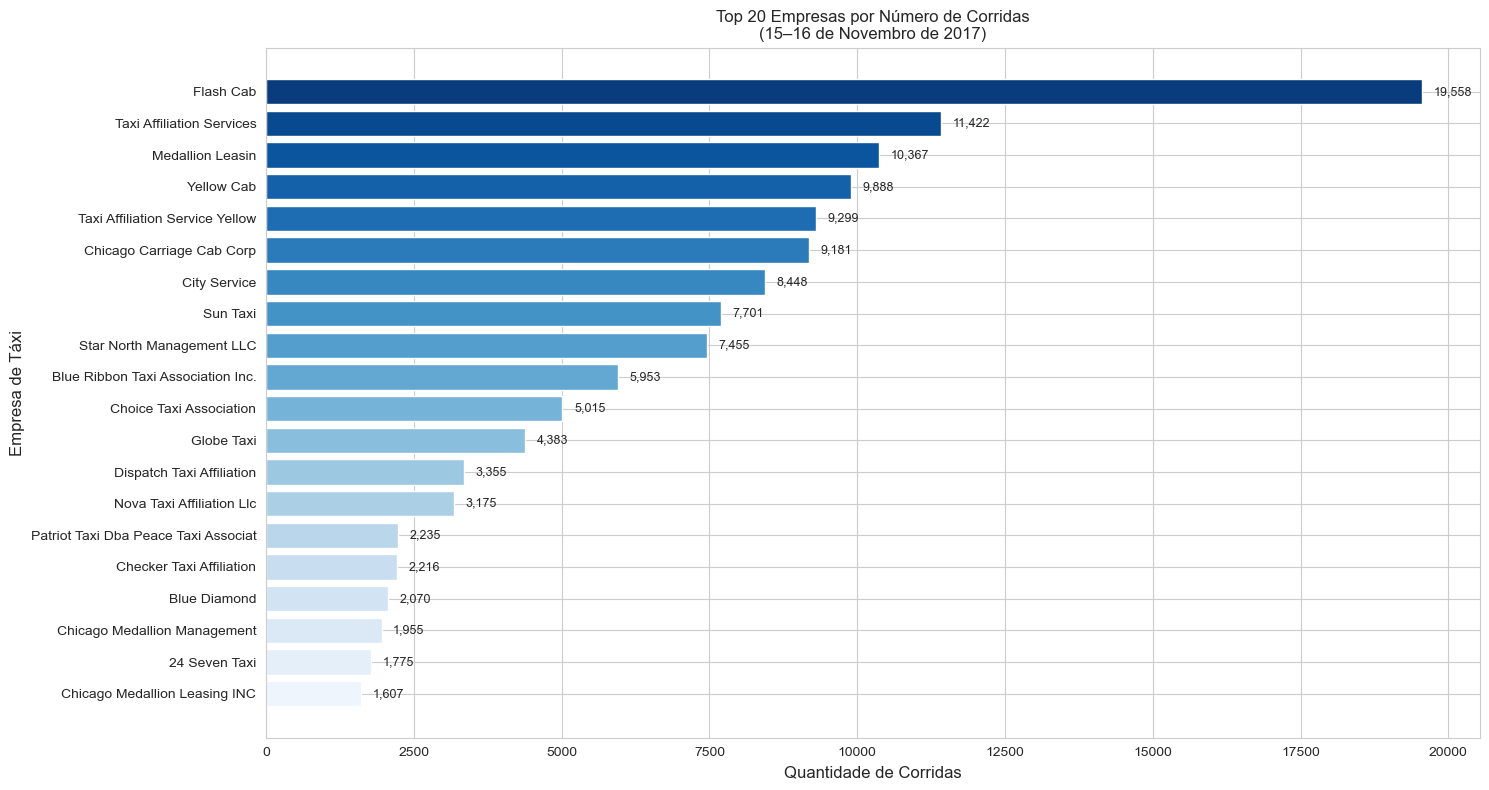

In [423]:
top20 = (df_1.groupby('nome_companhia')['quantidade_viagens'].sum().sort_values(ascending=False).head(20))

plt.figure(figsize=(15, 8)) 
sns.set_style("whitegrid")

bars = plt.barh(top20.index, top20.values, color=sns.color_palette("Blues_r", 20))

for bar in bars:
    width = bar.get_width()
    plt.text(width + max(top20.values)*0.01,bar.get_y() + bar.get_height()/2,f"{int(width):,}",va='center', fontsize=9)

# Titles & labels
plt.title("Top 20 Empresas por Número de Corridas\n(15–16 de Novembro de 2017)")
plt.xlabel("Quantidade de Corridas", fontsize=12)
plt.ylabel("Empresa de Táxi", fontsize=12)

plt.gca().invert_yaxis() 
plt.tight_layout()
plt.show()

### 4.3 - Selecionar top 10 bairros por média de corridas

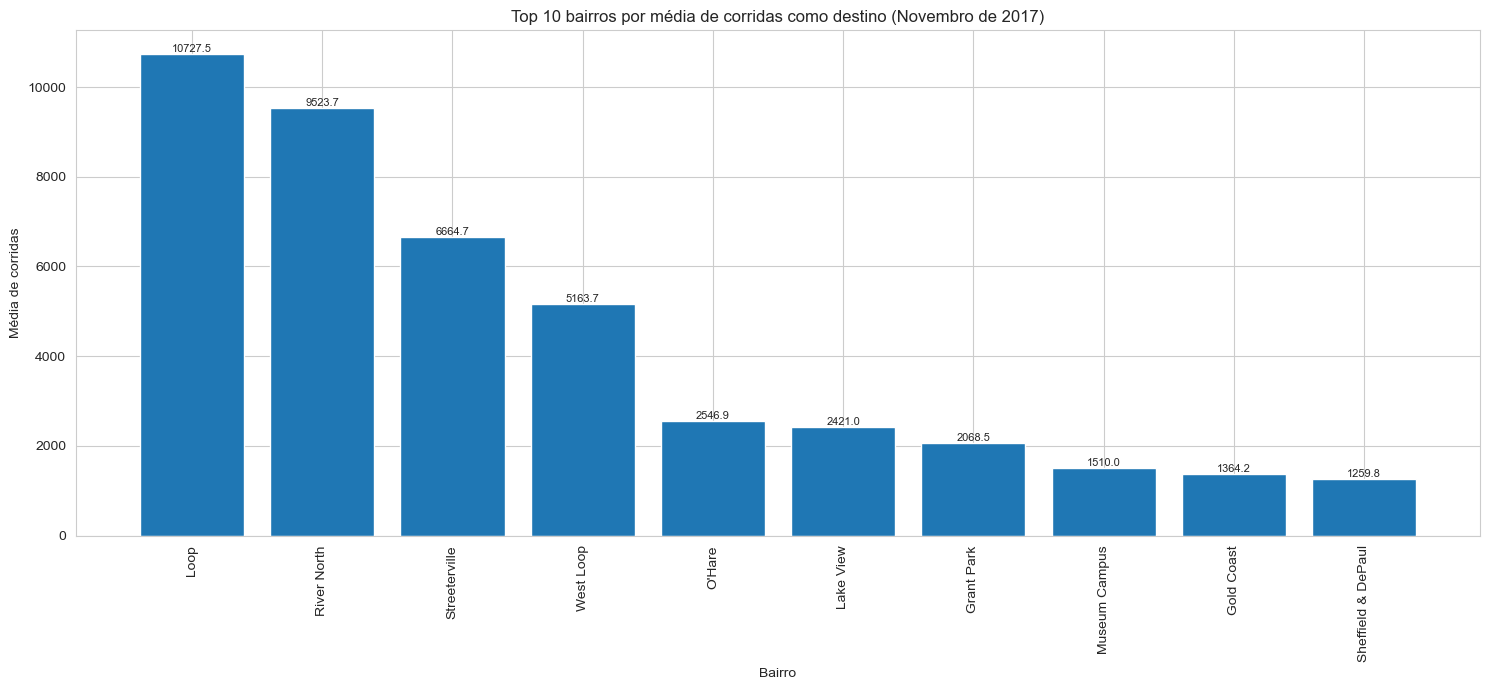

In [424]:
top10 = df_4.sort_values('media_viagens', ascending=False).head(10)

plt.figure(figsize=(15, 7))
bars = plt.bar(top10['bairro_destino'], top10['media_viagens'])

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,bar.get_height(),f'{bar.get_height():.1f}',ha='center', va='bottom', fontsize=8)

plt.xticks(rotation=90)
plt.title('Top 10 bairros por média de corridas como destino (Novembro de 2017)')
plt.xlabel('Bairro')
plt.ylabel('Média de corridas')
plt.tight_layout()
plt.show()

Com base nos gráficos e tabelas gerados, podemos identificar que as empresas de táxi mais populares são 'Flash Cab' liderando com o maior número de corridas, seguidas por 'Taxi Affiliation Services' e 'Medallion Leasin'.  
Além disso, os bairros mais populares como destinos de viagens são 'Loop' liderando com a maior média de corridas, seguidos por 'River North' e 'Streeterville'.

### 5 - Teste de hipotese

In [425]:
# Criar coluna com dia da semana (sábado = 5)
df_7['weekday'] = df_7['data_hora_inicio'].dt.weekday

# Filtrar apenas sábados
df_sat = df_7[df_7['weekday'] == 5]

# Separar grupos: chuvoso vs não chuvoso
rain = df_sat[df_sat['condicoes_climaticas'] == 'Bad']
no_rain = df_sat[df_sat['condicoes_climaticas'] == 'Good']
rain_durations = rain['duracao_segundos'] / 60
no_rain_durations = no_rain['duracao_segundos'] / 60

In [426]:
alpha = 0.05

results = stats.ttest_ind(rain_durations,no_rain_durations,equal_var=False  )
print("p-value:", results.pvalue)

if results.pvalue < alpha:
    print("Rejeitamos H0: a duração média MUDA em sábados chuvosos.")
else:
    print("Não rejeitamos H0: não há evidência de mudança na duração média.")

p-value: 6.738994326109027e-12
Rejeitamos H0: a duração média MUDA em sábados chuvosos.


A duração média das corridas do Loop para o Aeroporto O'Hare muda nos sábados chuvosos.
Hipóteses

H₀: a duração média é igual em sábados chuvosos e não chuvosos.

H₁: a duração média é diferente em sábados chuvosos.

Nível de significância

α = 0.05

Método

Foi aplicado o teste t de duas amostras independentes (Welch), pois estamos comparando a média de dois grupos independentes (chuvoso vs. seco) e as variâncias podem ser diferentes.

Critério

Se p-value < 0.05 → rejeita H₀ (a duração média muda).

Se p-value ≥ 0.05 → não rejeita H₀ (sem evidência de mudança).

### 6 - Conclusão

A análise integrada entre os dados de viagens e as condições meteorológicas permitiu identificar relações importantes entre clima, localização e duração das corridas em Chicago.
Os dataframes criados ao longo do projeto — contendo informações de viagens, clima horário e junções entre ambos — possibilitaram filtrar e comparar segmentos específicos, como corridas que saem do Loop e chegam ao Aeroporto O'Hare.

Os resultados mostraram que:

Nos sábados chuvosos, as corridas apresentaram maior duração média, sugerindo impacto direto das condições climáticas no trânsito e no tempo de deslocamento.

A combinação de joins entre tabelas meteorológicas e de viagens permitiu analisar somente as corridas com dados climáticos válidos, garantindo consistência.

O uso de filtros baseados em IDs de localização, dias da semana e condições de tempo demonstrou como diferentes fatores influenciam a operação das corridas.

De forma geral, o projeto evidencia a importância da integração entre múltiplas fontes de dados para compreender padrões urbanos e operacionais. Os dataframes finais fornecem uma base sólida para análises mais profundas, incluindo previsões, otimizações e identificação de anomalias no comportamento das viagens.